## Importing required libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression

## Loading the River Toxin Dataset

In [20]:
df=pd.read_csv("National_River_Toxin_Dataset_1.csv")
df.head()

,Date,River_System,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
0,2018-01-01,Amazon,7.030015,19.136212,2.500401,0.465454,3.578886,11.627614,0.522167,7.830196
1,2018-01-01,Nile,7.421766,21.406824,3.469443,0.859716,5.352155,10.538171,0.510465,8.130328
2,2018-01-01,Yangtze,7.133612,18.419902,3.806935,0.824085,5.277814,7.865033,0.585096,8.120874
3,2018-01-01,Mississippi,7.863001,18.014871,3.438131,0.500597,3.473881,11.143068,0.438248,6.853816
4,2018-01-01,Danube,7.527686,16.622289,2.188210,0.424178,2.454209,8.043467,0.422244,8.197925


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1305 non-null   object 
 1   River_System      1305 non-null   object 
 2   pH_Level          1278 non-null   float64
 3   Temperature       1278 non-null   float64
 4   Lead              1285 non-null   float64
 5   Mercury           1278 non-null   float64
 6   Arsenic           1279 non-null   float64
 7   Nitrates          1265 non-null   float64
 8   Phosphates        1282 non-null   float64
 9   Dissolved_Oxygen  1284 non-null   float64
dtypes: float64(8), object(2)
memory usage: 102.1+ KB


In [4]:
df.describe()

,pH_Level,Temperature,Lead,Mercury,Arsenic,Nitrates,Phosphates,Dissolved_Oxygen
count,1278.000000,1278.000000,1285.000000,1278.000000,1279.000000,1265.000000,1282.000000,1284.000000
mean,7.353247,20.041668,3.011035,0.596108,3.597916,10.038789,0.497162,8.023795
std,0.349114,4.063638,0.874431,0.175150,0.992052,2.096641,0.106304,1.064190
min,6.465087,9.891618,0.551349,0.157117,1.485608,2.025075,0.144044,5.041394
25%,7.101324,16.813976,2.366298,0.462683,2.836160,8.701188,0.422006,7.269386
50%,7.339326,20.039121,3.000714,0.599186,3.511678,10.089112,0.497631,8.007448
75%,7.585733,23.358634,3.676560,0.734863,4.298946,11.391686,0.572888,8.740828
max,8.392902,30.749449,5.800963,1.057494,6.232902,16.547073,0.870007,11.228677


In [5]:
df.dropna(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

## Analysis of River Toxic Levels

In [6]:
df['Toxic Levels'] = df['Lead'] + df['Mercury'] + df['Arsenic'] + df['Phosphates']
rivers_toxics = df.groupby('River_System')[(['Lead'] + ['Mercury'] + ['Arsenic'] + ['Phosphates'])].mean()
rivers_toxics['Toxic Levels'] = rivers_toxics['Lead'] + rivers_toxics['Mercury'] + rivers_toxics['Arsenic'] + rivers_toxics['Phosphates']
rivers_toxics['Toxic Levels']

River_System
Amazon          6.006203
Danube          5.916217
Mississippi     8.082753
Nile            8.199743
Yangtze        10.305147
Name: Toxic Levels, dtype: float64

In [7]:
rivers_toxics.sort_values('Toxic Levels', ascending=False)

,Lead,Mercury,Arsenic,Phosphates,Toxic Levels
River_System,,,,,
Yangtze,4.035085,0.790756,4.997301,0.482006,10.305147
Nile,2.976931,0.710474,4.015651,0.496687,8.199743
Mississippi,3.487375,0.600770,3.492275,0.502332,8.082753
Amazon,2.003854,0.495652,3.004700,0.501998,6.006203
Danube,2.533596,0.391695,2.496362,0.494565,5.916217


In [8]:
correlation = df['pH_Level'].corr(df['Toxic Levels'])
correlation

np.float64(0.21039595734774202)

## Data Visualisation

Text(0.5, 1.0, 'Average River Toxic Levels from 2018 to 2023')

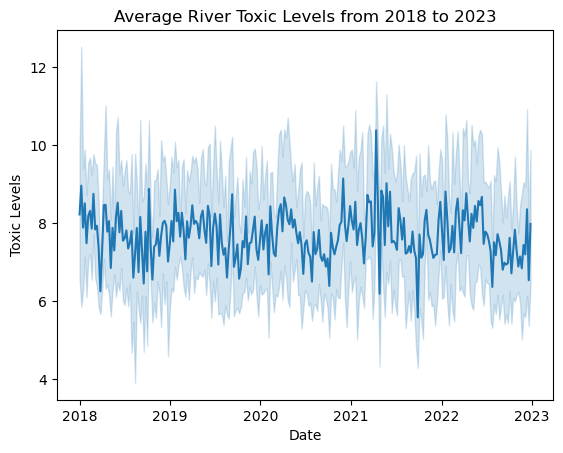

In [15]:
sns.lineplot(x='Date', y='Toxic Levels', data=df)
plt.title('Average River Toxic Levels from 2018 to 2023')

Text(0.5, 1.0, 'River Toxic Levels for Each River System from 2018 to 2023')

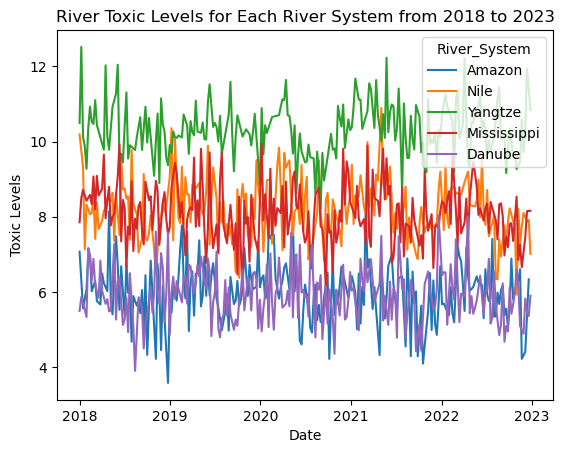

In [16]:
sns.lineplot(x='Date', y='Toxic Levels', data=df, hue='River_System')
plt.title('River Toxic Levels for Each River System from 2018 to 2023')

Text(0, 0.5, 'Toxic Levels')

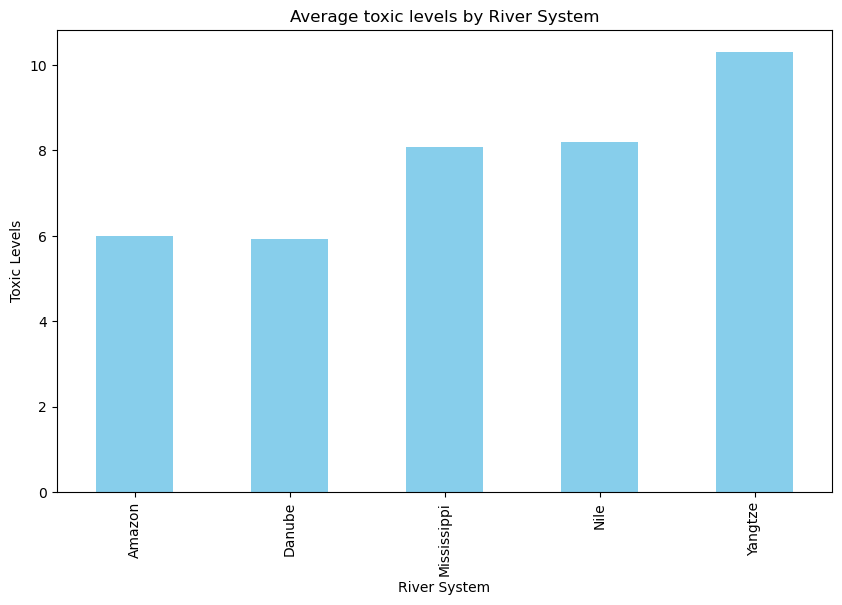

In [10]:
plt.figure(figsize=(10,6))
rivers_toxics['Toxic Levels'].plot(kind='bar', color='skyblue')
plt.title('Average toxic levels by River System')
plt.xlabel('River System')
plt.ylabel('Toxic Levels')

In [11]:
amazon = df[df['River_System'] == 'Amazon']['Lead']
nile = df[df['River_System'] == 'Nile']['Lead']
t_stat, p_value = stats.ttest_ind(amazon, nile)
print(f"T-test between Amazon and Nile: T-statistic = {t_stat}, P-value = {p_value}")

T-test between Amazon and Nile: T-statistic = -18.811069466055443, P-value = 2.3473547786390746e-58
